#Ciência de Dados: Análise de Dados Aplicada
##Trabalho final


###Aluno: Alan Nakamura Kageyama
###Ra: 2482053

##Bibliotecas

In [ ]:
import urllib.request
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import xgboost as xgb

import duckdb

##Fonte Principal: NYC Citywide Annualized Calendar Sales Update

###Pergunta
De que maneira a flutuação dos indicadores macroeconômicos e a densidade de criminalidade local influenciam a variação dos preços imobiliários nos diferentes distritos de Nova York?




###Hipoteses
Hipótese 1: Distritos com maior incidência de crimes graves apresentam uma desvalorização acentuada no preço por metro quadrado, sendo esta variável mais impactante em imóveis residenciais do que em comerciais.

Hipótese 2: A taxa de juros hipotecária é um preditor negativo do volume e preço dos imóveis.

Hipótese 3: Certos bairros apresentam uma "imunidade" maior a índices criminais elevados, mantendo preços estáveis devido à alta demanda, enquanto bairros periféricos são mais sensíveis tanto ao crime quanto à variação de juros.

Os dados dos anos de 2018-2021 são muito complicados por causa da pandemia. Por conta disso, decidi pegar os anos de 2022-2025.

###Carregando os dados

In [ ]:
print("Iniciando o download do dataset Principal. Isso pode levar alguns segundos!")

filename = "nyc_sales_raw.csv"
url = "https://data.cityofnewyork.us/api/views/w2pb-icbu/rows.csv?accessType=DOWNLOAD"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset Principal. Isso pode levar alguns segundos!
nyc_sales_raw.csv baixado com sucesso! Tamanho: 148.58 MB
Download foi finalizado!


###Analisando os dados

In [ ]:
df_nyc_sales = pd.read_csv('nyc_sales_raw.csv')
display(df_nyc_sales.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AS OF FINAL ROLL,BLOCK,LOT,EASE-MENT,BUILDING CLASS AS OF FINAL ROLL,ADDRESS,APARTMENT NUMBER,...,SALE PRICE,SALE DATE,Latitude,Longitude,Community Board,Council District,BIN,BBL,Census Tract 2020,Neighborhood Tabulation Area (NTA) (2020)
0,1,CHINATOWN,47 CONDO NON-BUSINESS STORAGE,4,172,1490,NaN,RS,"50 FRANKLIN STREET, S9B",S9B,...,1590000,06/21/2019,40.716951,-74.002500,101.0,1.0,1088222.0,1.001728e+09,31.0,MN0102
1,1,EAST VILLAGE,10 COOPS - ELEVATOR APARTMENTS,2,461,24,NaN,D4,"232 EAST 6TH STREET, 6D",NaN,...,515000,06/11/2019,40.727669,-73.989201,103.0,2.0,1006622.0,1.004610e+09,38.0,MN0303
2,1,FASHION,21 OFFICE BUILDINGS,4,779,23,NaN,O6,227 WEST 29TH STREET,NaN,...,0,05/03/2019,40.748263,-73.993857,105.0,3.0,1014284.0,1.007790e+09,95.0,MN0501
3,1,FASHION,13 CONDOS - ELEVATOR APARTMENTS,2,841,1044,NaN,R4,"16 WEST 40TH STREET, 26A",26A,...,5203258,03/11/2019,40.752505,-73.982574,105.0,4.0,1090404.0,1.008418e+09,84.0,MN0502
4,1,EAST VILLAGE,10 COOPS - ELEVATOR APARTMENTS,2,431,31,NaN,D4,"141 EAST THIRD STREET, 2E",NaN,...,975000,12/27/2019,40.723793,-73.985602,103.0,2.0,1005762.0,1.004310e+09,32.0,MN0303


In [ ]:
display(df_nyc_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845607 entries, 0 to 845606
Data columns (total 29 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   BOROUGH                                    845607 non-null  int64  
 1   NEIGHBORHOOD                               845607 non-null  object 
 2   BUILDING CLASS CATEGORY                    845607 non-null  object 
 3   TAX CLASS AS OF FINAL ROLL                 841424 non-null  object 
 4   BLOCK                                      845607 non-null  int64  
 5   LOT                                        845607 non-null  int64  
 6   EASE-MENT                                  0 non-null       float64
 7   BUILDING CLASS AS OF FINAL ROLL            841424 non-null  object 
 8   ADDRESS                                    845607 non-null  object 
 9   APARTMENT NUMBER                           208671 non-null  object 
 10  ZIP CODE

None

In [ ]:
display(df_nyc_sales.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
TAX CLASS AS OF FINAL ROLL,4183
BLOCK,0
LOT,0
EASE-MENT,845607
BUILDING CLASS AS OF FINAL ROLL,4183
ADDRESS,0
APARTMENT NUMBER,636936


###Limpeza de dados antes da integração

####Colunas para dropar
EASE-MENT: Coluna está completamente vazia.

APARTMENT NUMBER: Como estou analisando o impacto do bairro e indicadores macroeconômicos, o número exato do apartamento é um excesso de ruído.

BLOCK e LOT: Usarei o BOROUGH para integrar com os crimes. Deixar esses no modelo imagino que pode causar overfitting.

As outras são para questões administrativas, então podem ser retiradas.

In [ ]:
columns_to_drop = ['EASE-MENT', 'APARTMENT NUMBER', 'BLOCK', 'LOT', 'Community Board',
                   'Council District', 'BIN', 'BBL', 'Census Tract 2020', 'Neighborhood Tabulation Area (NTA) (2020)',
                   'TAX CLASS AS OF FINAL ROLL', 'BUILDING CLASS AS OF FINAL ROLL']
df_nyc_sales = df_nyc_sales.drop(columns=columns_to_drop)

####Linhas para dropar, outliers e valores nulos
SALE_PRICE: Nula ou menor que 10.000, valores de 0 a 10.000 geralmente são trocas que não envolvem dinheiro ou heranças, e não vendas reais a preço de mercado.

SALE_DATE: Só é necessário o periodo de 2022-2025

ZIP_CODE: Nulo ou igual a 0, não é possivel integrar com a tabela de crimes nem descobrir se a escola vizinha é boa.

Latitude e Longitude são dados interessantes de ter, por isso vou eliminar as linhas com valores nulos.

Vendas duplicadas: Foram identificados algumas vendas duplicadas.

GROSS SQUARE FEET: Algumas linhas possuem valores muito baixos.

In [ ]:
linhas_antes = df_nyc_sales.shape[0]

df_nyc_sales.dropna(subset=['SALE PRICE'], inplace=True)
df_nyc_sales = df_nyc_sales[df_nyc_sales['SALE PRICE'] > 10000]

df_nyc_sales.dropna(subset=['ZIP CODE'], inplace=True)
df_nyc_sales = df_nyc_sales[df_nyc_sales['ZIP CODE'] > 0]

df_nyc_sales.dropna(subset=['Latitude', 'Longitude'], inplace=True)

df_nyc_sales.drop_duplicates(inplace=True)

df_nyc_sales['SALE DATE'] = pd.to_datetime(df_nyc_sales['SALE DATE'])
df_nyc_sales = df_nyc_sales[df_nyc_sales['SALE DATE'].dt.year.between(2022, 2025)]

In [ ]:
area_minima = 100

df_nyc_sales['GROSS SQUARE FEET'] = pd.to_numeric(
    df_nyc_sales['GROSS SQUARE FEET'].astype(str).str.replace(',', ''),
    errors='coerce'
)
df_nyc_sales.dropna(subset=['GROSS SQUARE FEET'], inplace=True)


df_nyc_sales = df_nyc_sales[
    (df_nyc_sales['GROSS SQUARE FEET'] >= area_minima)
].copy()

linhas_depois = df_nyc_sales.shape[0]
print(f"linhas removidas: {linhas_antes - linhas_depois} linhas descartadas.")

linhas removidas: 751750 linhas descartadas.


In [ ]:
print(f"New shape of df_nyc_sales: {df_nyc_sales.shape}")

New shape of df_nyc_sales: (93857, 17)


In [ ]:
display(df_nyc_sales.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


####Padronizando os dados que seram usados para a integração
Aqui o formato após a conversão é string (YYYY-MM)

Garantindo que o borough ta no formato certo

In [ ]:
df_nyc_sales['SALE DATE'] = df_nyc_sales['SALE DATE'].dt.strftime('%Y-%m')
df_nyc_sales['BOROUGH'] = df_nyc_sales['BOROUGH'].astype(int)

In [ ]:
if not os.path.exists('dados'):
    os.makedirs('dados')

df_nyc_sales.to_parquet('dados/nyc_vendas_limpo_sem_integracao.parquet', index=False)
print("Dataset de vendas limpo sem integração salvo com sucesso na pasta 'dados'!")

Dataset de vendas limpo sem integração salvo com sucesso na pasta 'dados'!


##Enriquecimento com Fontes Externa

###NYPD Complaint Data Historic

As vezes esses dados não baixam corretamente, se mantenha atento a isso.

####Carregando os dados

In [ ]:
print("Iniciando o download do dataset NYPD Complaint Data Historic. Arquivo muito grande! Isso pode levar alguns minutos dependendo da sua internet...")

filename = "nypd_crimes_raw.csv"
url = "https://data.cityofnewyork.us/api/views/qgea-i56i/rows.csv?accessType=DOWNLOAD"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset NYPD Complaint Data Historic. Arquivo muito grande! Isso pode levar alguns minutos dependendo da sua internet...
nypd_crimes_raw.csv baixado com sucesso! Tamanho: 3270.30 MB
Download foi finalizado!


####Analisando os dados

In [ ]:
con = duckdb.connect()

#####Reduzindo o Dataset para apenas o periodo de 2022-2025

In [ ]:
print("Lendo o arquivo e filtrando apenas os anos de 2022 a 2025...")

query = """
    SELECT
        RPT_DT,
        BORO_NM,
        LAW_CAT_CD
    FROM read_csv_auto('nypd_crimes_raw.csv', all_varchar=true)
    WHERE
        CAST(str_split(RPT_DT, '/')[3] AS INTEGER) BETWEEN 2022 AND 2025
"""

df_crimes_filtrados = con.execute(query).df()

print(f"Sucesso! O dataset filtrado tem {df_crimes_filtrados.shape[0]} linhas.")

Lendo o arquivo e filtrando apenas os anos de 2022 a 2025...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sucesso! O dataset filtrado tem 2243782 linhas.


In [ ]:
display(df_crimes_filtrados.head())

,RPT_DT,BORO_NM,LAW_CAT_CD
0,03/15/2022,BRONX,FELONY
1,03/18/2022,BRONX,FELONY
2,06/23/2022,BROOKLYN,FELONY
3,08/20/2022,BRONX,VIOLATION
4,03/08/2022,BRONX,VIOLATION


In [ ]:
display(df_crimes_filtrados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243782 entries, 0 to 2243781
Data columns (total 3 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   RPT_DT      object
 1   BORO_NM     object
 2   LAW_CAT_CD  object
dtypes: object(3)
memory usage: 51.4+ MB


None

In [ ]:
display(df_crimes_filtrados.isnull().sum())

,0
RPT_DT,0
BORO_NM,0
LAW_CAT_CD,0


####Limpando e padronizando os dados

In [ ]:
#Data que ocorreu e o nome do distrito
df_crimes = df_crimes_filtrados.dropna(subset=['RPT_DT', 'BORO_NM']).copy()

dict_boroughs = {
    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5
}
df_crimes['borough_code'] = df_crimes['BORO_NM'].map(dict_boroughs)

df_crimes.dropna(subset=['borough_code'], inplace=True)

# Criando a chave Ano-Mês no formato YYYY-MM
df_crimes['RPT_DT'] = pd.to_datetime(df_crimes['RPT_DT'], errors='coerce')
df_crimes.dropna(subset=['RPT_DT'], inplace=True)
df_crimes['ano_mes'] = df_crimes['RPT_DT'].dt.strftime('%Y-%m')

#Contando quantos crimes graves e leves ocorreram por Bairro e por Mês
df_crimes_preparado = df_crimes.groupby(['borough_code', 'ano_mes']).apply(
    lambda x: pd.Series({
        'qtd_crimes_graves': (x['LAW_CAT_CD'] == 'FELONY').sum(),
        'qtd_crimes_leves': (x['LAW_CAT_CD'] == 'MISDEMEANOR').sum()
    })
).reset_index()

df_crimes_preparado['borough_code'] = df_crimes_preparado['borough_code'].astype(int)

print(f"Total de linhas agregadas: {df_crimes_preparado.shape[0]}")
display(df_crimes_preparado.head())

Total de linhas agregadas: 240


/tmp/ipykernel_3955/780189284.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_crimes_preparado = df_crimes.groupby(['borough_code', 'ano_mes']).apply(


,borough_code,ano_mes,qtd_crimes_graves,qtd_crimes_leves
0,1,2022-01,3262,4738
1,1,2022-02,3284,5343
2,1,2022-03,3647,6308
3,1,2022-04,3664,5956
4,1,2022-05,3971,6222


In [ ]:
if not os.path.exists('dados'):
    os.makedirs('dados')

df_crimes_preparado.to_parquet('dados/crimes_agregados_mensal.parquet', index=False)
print("Arquivo salvo com sucesso na pasta 'dados'!")

Arquivo salvo com sucesso na pasta 'dados'!


###FRED - 30-Year Fixed Rate Mortgage Average

####Carregando os dados

In [ ]:
print("Iniciando o download do dataset 30-Year Fixed Rate Mortgage Average.")

filename = "macro_economics_usa.csv"
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset 30-Year Fixed Rate Mortgage Average.
macro_economics_usa.csv baixado com sucesso! Tamanho: 0.04 MB
Download foi finalizado!


####Analisando os dados

In [ ]:
df_juros = pd.read_csv('macro_economics_usa.csv')

display(df_juros.head())

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [ ]:
df_juros['observation_date'] = pd.to_datetime(df_juros['observation_date'], errors='coerce')

# filtrando o dataset para os anos 2022-2025
df_juros = df_juros[df_juros['observation_date'].dt.year.between(2022, 2025)]

df_juros['ano_mes'] = df_juros['observation_date'].dt.strftime('%Y-%m')

display(df_juros.head())

,observation_date,MORTGAGE30US,ano_mes
2649,2022-01-06,3.22,2022-01
2650,2022-01-13,3.45,2022-01
2651,2022-01-20,3.56,2022-01
2652,2022-01-27,3.55,2022-01
2653,2022-02-03,3.55,2022-02


Padronização dos dados para integração

In [ ]:
df_juros_preparado = df_juros.groupby('ano_mes')['MORTGAGE30US'].mean().reset_index()

df_juros_preparado.rename(columns={'MORTGAGE30US': 'media_juros_hipoteca'}, inplace=True)

display(df_juros_preparado.head())

,ano_mes,media_juros_hipoteca
0,2022-01,3.4450
1,2022-02,3.7625
2,2022-03,4.1720
3,2022-04,4.9825
4,2022-05,5.2300


###Integrando ao Dataset principal

A integração vai ser pelo codigo de distritos(borough) e mês/ano. Como no dataset principal, o distrito era identificado por id, foi necessário transformar o borough desse dataset em código.

In [ ]:
# Bairro e o mês de venda com o bairro e o mês do crime
df_integrado_1 = pd.merge(
    df_nyc_sales,
    df_crimes_preparado,
    left_on=['BOROUGH', 'SALE DATE'],
    right_on=['borough_code', 'ano_mes'],
    how='left'
)

# 'borough_code' ficou duplicado
df_integrado_1.drop(columns=['borough_code'], errors='ignore', inplace=True)

df_dataset_final = pd.merge(
    df_integrado_1,
    df_juros_preparado,
    on='ano_mes',
    how='left'
)

print(f"Integração concluída! O formato final do dataset é: {df_dataset_final.shape}")

Integração concluída! O formato final do dataset é: (93857, 21)


In [ ]:
display(df_dataset_final.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,ano_mes,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,416 EAST 180TH STREET,10457.0,1.0,0.0,1.0,"1,575",1374.0,...,1,A5,362000,2025-06,40.852139,-73.897621,2025-06,4011,5541,6.8175
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,4449 PARK AVENUE,10457.0,1.0,0.0,1.0,"1,668",1497.0,...,1,A1,520000,2025-09,40.853545,-73.896014,2025-09,3886,5419,6.3525
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,2058 BATHGATE AVENUE,10457.0,1.0,0.0,1.0,"1,173",1516.0,...,1,A1,500000,2025-12,40.850237,-73.895253,2025-12,3190,4867,6.1900
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457.0,1.0,0.0,1.0,"1,668",1497.0,...,1,A1,615000,2024-12,40.853515,-73.896028,2024-12,3269,5063,6.7150
4,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVENUE,10458.0,1.0,0.0,1.0,913,1248.0,...,1,A1,655000,2025-12,40.855847,-73.891755,2025-12,3190,4867,6.1900


In [ ]:
display(df_dataset_final.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


In [ ]:
df_dataset_final.to_parquet('dados/nyc_vendas_integrado_bruto.parquet', index=False)

##Limpeza de Dados

###Missing values

####Aplicando KNN-Imputer

In [ ]:
from tqdm.notebook import tqdm #adição da barrinha de progresso

for col in ['GROSS SQUARE FEET', 'LAND SQUARE FEET']:
    df_dataset_final[col] = pd.to_numeric(df_dataset_final[col].astype(str).str.replace(',', ''), errors='coerce')

pedacos_imputados = []

#aqui fiz por bairro apenas para poder acompanhar o progresso
for bairro, df_bairro in tqdm(df_dataset_final.groupby('BOROUGH'), desc="Processando Bairros"):

    colunas_knn = ['SALE PRICE', 'Latitude', 'Longitude', 'YEAR BUILT', 'GROSS SQUARE FEET', 'LAND SQUARE FEET']
    df_num = df_bairro[colunas_knn].copy()

    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns, index=df_num.index)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    df_imputed_scaled = pd.DataFrame(imputer.fit_transform(df_scaled), columns=df_num.columns, index=df_num.index)

    df_imputed = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=df_num.columns, index=df_num.index)

    df_bairro_pronto = df_bairro.copy()
    for col in colunas_knn:
        df_bairro_pronto[col] = df_imputed[col]

    pedacos_imputados.append(df_bairro_pronto)

df_dataset_final = pd.concat(pedacos_imputados).sort_index()

print("Imputação com KNN concluída")

Processando Bairros:   0%|          | 0/5 [00:00<?, ?it/s]

Imputação com KNN concluída


In [ ]:
display(df_dataset_final.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


In [ ]:
display(df_dataset_final.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,ano_mes,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,416 EAST 180TH STREET,10457.0,1.0,0.0,1.0,1575.0,1374.0,...,1,A5,362000.0,2025-06,40.852139,-73.897621,2025-06,4011,5541,6.8175
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,4449 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,520000.0,2025-09,40.853545,-73.896014,2025-09,3886,5419,6.3525
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,2058 BATHGATE AVENUE,10457.0,1.0,0.0,1.0,1173.0,1516.0,...,1,A1,500000.0,2025-12,40.850237,-73.895253,2025-12,3190,4867,6.1900
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,615000.0,2024-12,40.853515,-73.896028,2024-12,3269,5063,6.7150
4,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVENUE,10458.0,1.0,0.0,1.0,913.0,1248.0,...,1,A1,655000.0,2025-12,40.855847,-73.891755,2025-12,3190,4867,6.1900


###Inconsistências

In [ ]:
df_dataset_final['TOTAL UNITS'] = df_dataset_final['RESIDENTIAL UNITS'] + df_dataset_final['COMMERCIAL UNITS']

###Padronização

In [ ]:
df_dataset_final['ZIP CODE'] = df_dataset_final['ZIP CODE'].astype(int).astype(str)
df_dataset_final['NEIGHBORHOOD'] = df_dataset_final['NEIGHBORHOOD'].str.strip().str.upper()
df_dataset_final['BUILDING CLASS CATEGORY'] = df_dataset_final['BUILDING CLASS CATEGORY'].str.strip().str.upper()

if 'ano_mes' in df_dataset_final.columns:
    df_dataset_final.drop(columns=['ano_mes'], inplace=True)


##Dataset Final

In [ ]:
display(df_dataset_final.head())
display(df_dataset_final.info())
df_dataset_final.to_parquet('dados/nyc_dados_finais_limpos.parquet', index=False)

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,416 EAST 180TH STREET,10457,1.0,0.0,1.0,1575.0,1374.0,1899.0,1,A5,362000.0,2025-06,40.852139,-73.897621,4011,5541,6.8175
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,4449 PARK AVENUE,10457,1.0,0.0,1.0,1668.0,1497.0,1899.0,1,A1,520000.0,2025-09,40.853545,-73.896014,3886,5419,6.3525
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,2058 BATHGATE AVENUE,10457,1.0,0.0,1.0,1173.0,1516.0,1910.0,1,A1,500000.0,2025-12,40.850237,-73.895253,3190,4867,6.1900
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457,1.0,0.0,1.0,1668.0,1497.0,1899.0,1,A1,615000.0,2024-12,40.853515,-73.896028,3269,5063,6.7150
4,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVENUE,10458,1.0,0.0,1.0,913.0,1248.0,1901.0,1,A1,655000.0,2025-12,40.855847,-73.891755,3190,4867,6.1900


<class 'pandas.core.frame.DataFrame'>
Index: 93857 entries, 0 to 93856
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BOROUGH                         93857 non-null  int64  
 1   NEIGHBORHOOD                    93857 non-null  object 
 2   BUILDING CLASS CATEGORY         93857 non-null  object 
 3   ADDRESS                         93857 non-null  object 
 4   ZIP CODE                        93857 non-null  object 
 5   RESIDENTIAL UNITS               93857 non-null  float64
 6   COMMERCIAL UNITS                93857 non-null  float64
 7   TOTAL UNITS                     93857 non-null  float64
 8   LAND SQUARE FEET                93857 non-null  float64
 9   GROSS SQUARE FEET               93857 non-null  float64
 10  YEAR BUILT                      93857 non-null  float64
 11  TAX CLASS AT TIME OF SALE       93857 non-null  int64  
 12  BUILDING CLASS AT TIME OF SALE  93857

None

O Dataset final ficou com 84968 linhas e 20 colunas. Para fins de comparação, outro dataset das vendas sem a integração também foi criado.

##Análise Exploratória e Consultas SQL

###Reestruturação Necessária


####Normalização da Data

In [ ]:
df_dataset_final['SALE DATE'] = pd.to_datetime(df_dataset_final['SALE DATE'])
df_dataset_final['sale_year'] = df_dataset_final['SALE DATE'].dt.year
df_dataset_final['sale_month'] = df_dataset_final['SALE DATE'].dt.month
df_dataset_final['sale_day_of_week'] = df_dataset_final['SALE DATE'].dt.dayofweek


####Corrigindo alguns tipos numéricos

In [ ]:
cols_para_int = ['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT']
for col in cols_para_int:
    df_dataset_final[col] = df_dataset_final[col].astype(int)

####Padronização de tipos

In [ ]:
cols_categoricas = [
    'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
    'ZIP CODE', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE'
]
for col in cols_categoricas:
    df_dataset_final[col] = df_dataset_final[col].astype('category')

cols_para_remover = ['ADDRESS', 'SALE DATE']
df_dataset_final.drop(columns=cols_para_remover, inplace=True, errors='ignore')

####parquet final limpo 2.0

In [ ]:
df_dataset_final.to_parquet('dados/nyc_dados_finais_limpos_v2.parquet', index=False)
print(df_dataset_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 93857 entries, 0 to 93856
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         93857 non-null  category
 1   NEIGHBORHOOD                    93857 non-null  category
 2   BUILDING CLASS CATEGORY         93857 non-null  category
 3   ZIP CODE                        93857 non-null  category
 4   RESIDENTIAL UNITS               93857 non-null  int64   
 5   COMMERCIAL UNITS                93857 non-null  int64   
 6   TOTAL UNITS                     93857 non-null  int64   
 7   LAND SQUARE FEET                93857 non-null  float64 
 8   GROSS SQUARE FEET               93857 non-null  float64 
 9   YEAR BUILT                      93857 non-null  int64   
 10  TAX CLASS AT TIME OF SALE       93857 non-null  category
 11  BUILDING CLASS AT TIME OF SALE  93857 non-null  category
 12  SALE PRICE             

###Consultas SQL

In [ ]:
path_parquet = 'dados/nyc_dados_finais_limpos_v2.parquet'

####Análise Macro por Bairro

Analisa o preço por bairro e verefica o preço por metro quadrado

In [ ]:
query1 = f"""
    SELECT
        BOROUGH,
        COUNT(*) as total_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio,
        ROUND(AVG("GROSS SQUARE FEET"), 2) as area_media,
        ROUND(AVG("SALE PRICE") / NULLIF(AVG("GROSS SQUARE FEET"), 0), 2) as preco_por_sqft,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves_mes
    FROM '{path_parquet}'
    GROUP BY BOROUGH
    ORDER BY preco_medio DESC
"""

df_analise_bairros = con.execute(query1).df()
display(df_analise_bairros)

,BOROUGH,total_vendas,preco_medio,area_media,preco_por_sqft,media_crimes_graves_mes
0,1,4209,16535331.99,66509.45,248.62,3775.0
1,3,28143,2187937.62,7928.56,275.96,4271.0
2,2,10273,1603960.25,10123.90,158.43,3502.0
3,4,35139,1260533.40,2600.27,484.77,3378.0
4,5,16093,827067.68,2035.34,406.35,535.0


/tmp/ipykernel_3955/3243275923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analise_bairros, x='BOROUGH', y='preco_por_sqft', palette='viridis')


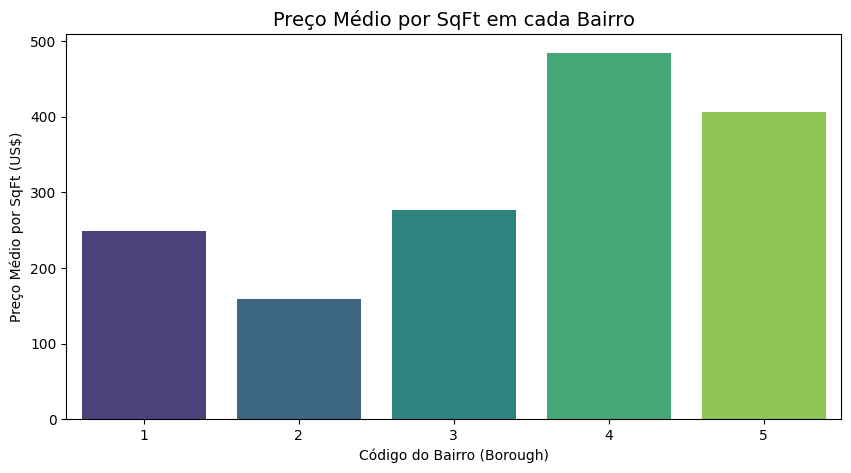

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_analise_bairros, x='BOROUGH', y='preco_por_sqft', palette='viridis')
plt.title('Preço Médio por SqFt em cada Bairro', fontsize=14)
plt.xlabel('Código do Bairro (Borough)')
plt.ylabel('Preço Médio por SqFt (US$)')
plt.show()

todo: alterar nome no grafico

    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5


####Impacto dos Juros



Analisando se a taxa de juros impacta de alguma forma o volume de vendas:

In [ ]:
query2 = f"""
    SELECT
        media_juros_hipoteca,
        COUNT(*) as volume_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio
    FROM '{path_parquet}'
    GROUP BY media_juros_hipoteca
    ORDER BY media_juros_hipoteca ASC
"""

df_juros = con.execute(query2).df()
display(df_juros)

,media_juros_hipoteca,volume_vendas,preco_medio
0,3.4450,2371,1853616.25
1,3.7625,2298,1815367.26
2,4.1720,2673,4074125.38
3,4.9825,2244,2889943.53
4,5.2225,2456,1789793.45
5,5.2300,2604,2003268.35
6,5.4125,2390,1968927.88
7,5.5220,2844,2628599.75
8,6.1120,2248,2109690.59
9,6.1800,1954,2358721.77


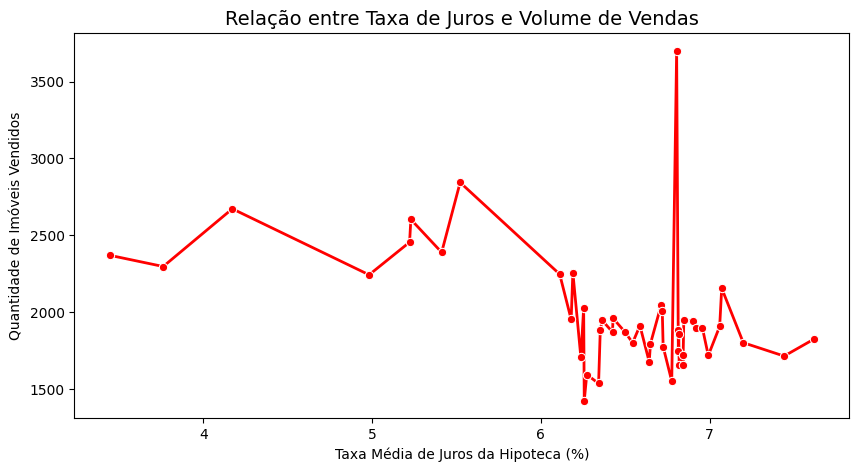

In [ ]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_juros, x='media_juros_hipoteca', y='volume_vendas', marker='o', color='red', linewidth=2)
plt.title('Relação entre Taxa de Juros e Volume de Vendas', fontsize=14)
plt.xlabel('Taxa Média de Juros da Hipoteca (%)')
plt.ylabel('Quantidade de Imóveis Vendidos')
plt.show()

####Categorias de Imóveis vs Crimes

Verifica se os imóveis populares estão localizados em zonas com médias criminais mais altas em comparação aos imóveis de luxo.

In [ ]:
query3 = f"""
    SELECT
        CASE
            WHEN "SALE PRICE" >= 2000000 THEN '1. Luxo (> $2M)'
            WHEN "SALE PRICE" < 500000 THEN '3. Popular (< $500k)'
            ELSE '2. Intermediário'
        END as categoria_imovel,
        COUNT(*) as qtd_vendas,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves,
        ROUND(AVG(qtd_crimes_leves), 0) as media_crimes_leves
    FROM '{path_parquet}'
    GROUP BY categoria_imovel
    ORDER BY categoria_imovel ASC
"""

df_luxo = con.execute(query3).df()
display(df_luxo)

,categoria_imovel,qtd_vendas,media_crimes_graves,media_crimes_leves
0,1. Luxo (> $2M),12808,3882.0,5987.0
1,2. Intermediário,71833,3121.0,4794.0
2,3. Popular (< $500k),9216,2767.0,4275.0


/tmp/ipykernel_3955/4277088676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_luxo, x='categoria_imovel', y='media_crimes_graves', palette='magma')


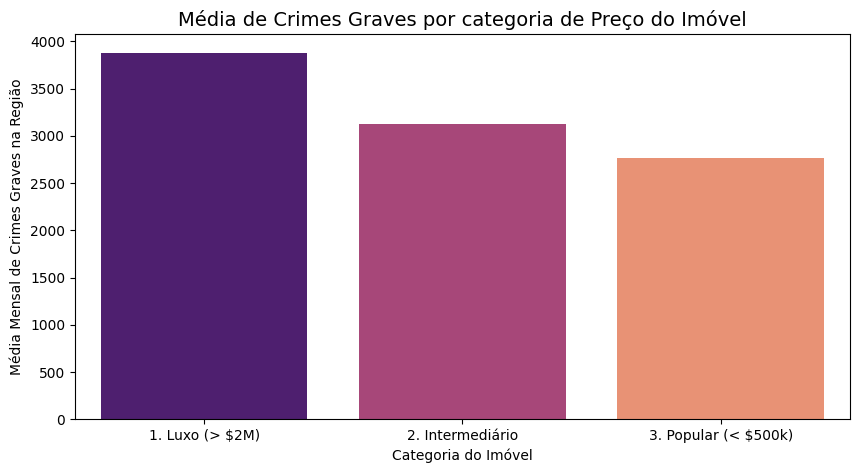

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_luxo, x='categoria_imovel', y='media_crimes_graves', palette='magma')
plt.title('Média de Crimes Graves por categoria de Preço do Imóvel', fontsize=14)
plt.xlabel('Categoria do Imóvel')
plt.ylabel('Média Mensal de Crimes Graves na Região')
plt.show()

Esse resultado pode ser explicado pela teoria da centralidade urbana e densidade demográfica de Nova York. Os imóveis de altíssimo padrão estão concentrados no núcleo central da cidade, regiões que atraem diariamente milhões de trabalhadores e turistas, além de concentrarem grande fluxo de capital. Essa extrema densidade de oportunidades eleva os números absolutos de registros criminais nas delegacias locais. Por outro lado, o mercado 'Popular' se localiza em zonas periféricas e predominantemente residenciais dos distritos externos, que possuem menor densidade populacional flutuante e, consequentemente, menor contagem absoluta de ocorrências.

####Sazonalidade de Vendas e Crimes

Verifica se há picos de vendas em algum mês e se há alguma correlação com o aumento da criminalidade nessas épocas.

In [ ]:
query4 = f"""
    SELECT
        sale_month as mes,
        COUNT(*) as total_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio_venda,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves
    FROM '{path_parquet}'
    GROUP BY sale_month
    ORDER BY sale_month ASC
"""

df_sazonalidade = con.execute(query4).df()
display(df_sazonalidade)

,mes,total_vendas,preco_medio_venda,media_crimes_graves
0,1,7542,1915151.53,3028.0
1,2,6938,1827278.04,2826.0
2,3,7930,2546317.92,3108.0
3,4,7279,2295602.31,3104.0
4,5,8272,1865303.71,3343.0
5,6,8652,2351439.22,3286.0
6,7,8068,2069233.42,3434.0
7,8,8398,2226619.85,3412.0
8,9,7891,2136204.16,3302.0
9,10,7760,1945757.74,3288.0


/tmp/ipykernel_3955/104706544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sazonalidade, x='mes', y='total_vendas', palette='Blues_d')


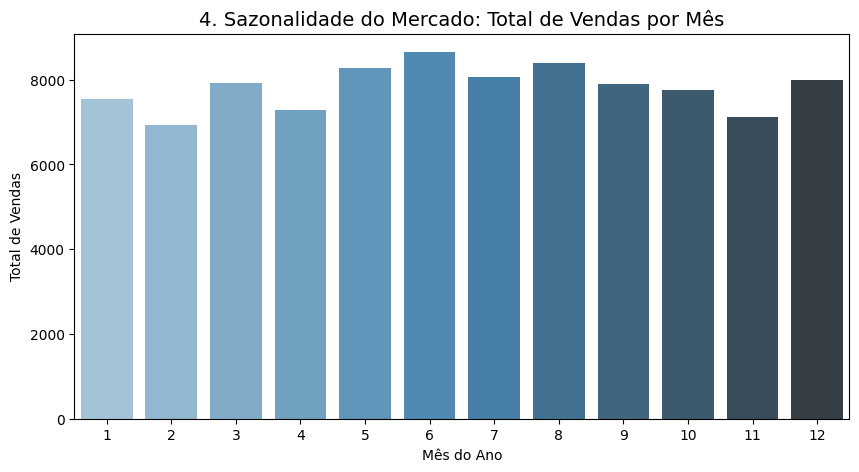

/tmp/ipykernel_3955/104706544.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sazonalidade, x='mes', y='media_crimes_graves', palette='Reds_d')


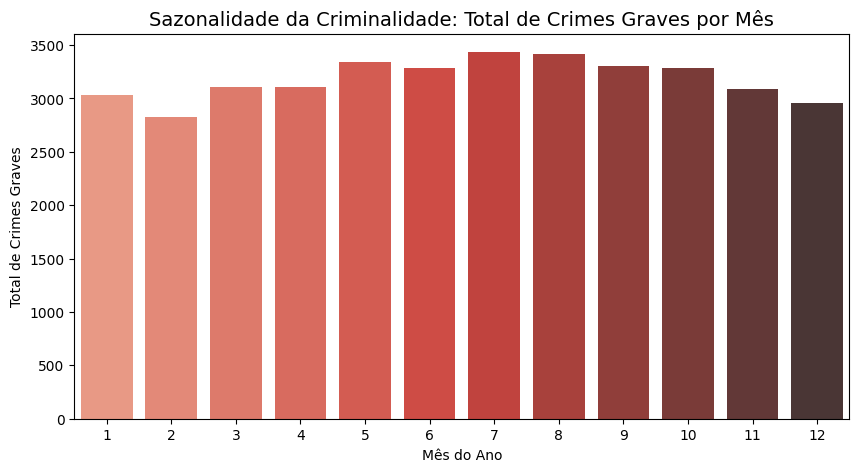

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sazonalidade, x='mes', y='total_vendas', palette='Blues_d')
plt.title('4. Sazonalidade do Mercado: Total de Vendas por Mês', fontsize=14)
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Vendas')
plt.show()
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sazonalidade, x='mes', y='media_crimes_graves', palette='Reds_d')
plt.title('Sazonalidade da Criminalidade: Total de Crimes Graves por Mês', fontsize=14)
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Crimes Graves')
plt.show()

Essa correlação evidencia o fator climático/sazonal como uma variável de confusão: meses mais quentes aumentam a circulação de capital e pessoas, aquecendo o mercado imobiliário, mas também aumentando a exposição a crimes. Para a etapa de Machine Learning, isso justifica a manutenção da variável 'Mês', para que o algoritmo não penalize erroneamente o preço de um imóvel vendido em Julho apenas por causa do pico natural de crimes daquela época.

####Micro-localização

Mostra ao avaliador os bairros específicos mais valorizados e com liquidez

In [ ]:
query5 = f"""
    SELECT
        NEIGHBORHOOD,
        BOROUGH,
        COUNT(*) as volume_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio
    FROM '{path_parquet}'
    GROUP BY NEIGHBORHOOD, BOROUGH
    HAVING COUNT(*) > 100
    ORDER BY preco_medio DESC
    LIMIT 10
"""

df_top_bairros = con.execute(query5).df()
display(df_top_bairros)

,NEIGHBORHOOD,BOROUGH,volume_vendas,preco_medio
0,UPPER WEST SIDE (59-79),1,114,55954171.11
1,MIDTOWN WEST,1,108,42384122.06
2,UPPER EAST SIDE (59-79),1,323,25321459.61
3,SOHO,1,131,23794122.26
4,MURRAY HILL,1,108,21608344.46
5,CHELSEA,1,162,15328389.15
6,WILLIAMSBURG-NORTH,3,181,14945840.21
7,UPPER EAST SIDE (79-96),1,212,13343561.27
8,GREENWICH VILLAGE-WEST,1,247,12820925.82
9,UPPER WEST SIDE (79-96),1,178,12072968.24


/tmp/ipykernel_3955/4006602141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_bairros, y='NEIGHBORHOOD', x='preco_medio', palette='rocket')


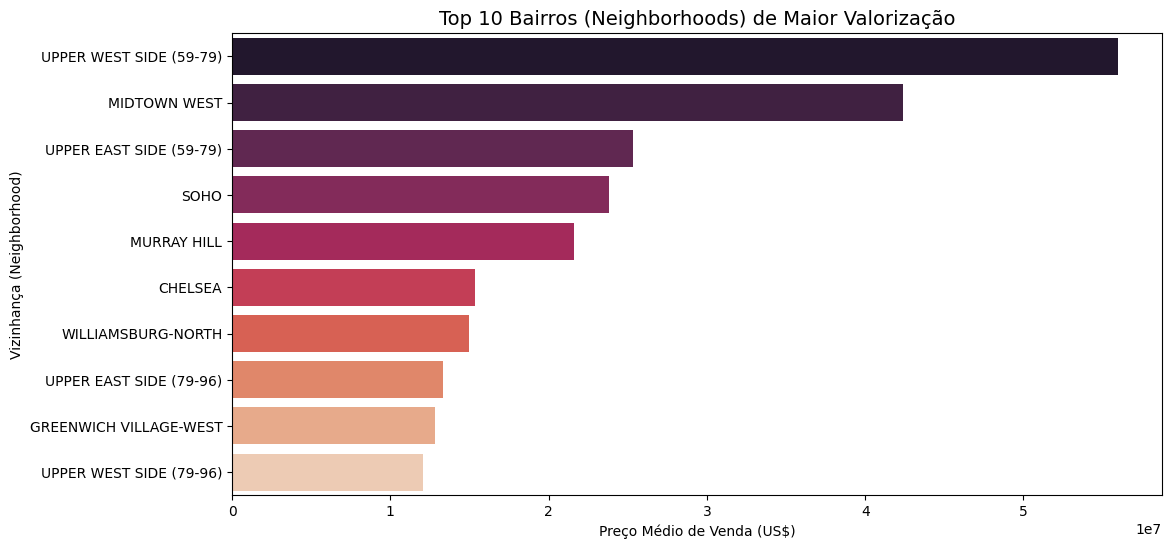

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_bairros, y='NEIGHBORHOOD', x='preco_medio', palette='rocket')
plt.title('Top 10 Bairros (Neighborhoods) de Maior Valorização', fontsize=14)
plt.xlabel('Preço Médio de Venda (US$)')
plt.ylabel('Vizinhança (Neighborhood)')
plt.show()

####Hipotese 1 - Segurança vs. Tipo de Propriedade

Para testar a Hipótese 1, realizamos uma agregação dos dados em formato de painel , agrupando as transações por Distrito, Mês de Venda e Tipo de Imóvel

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


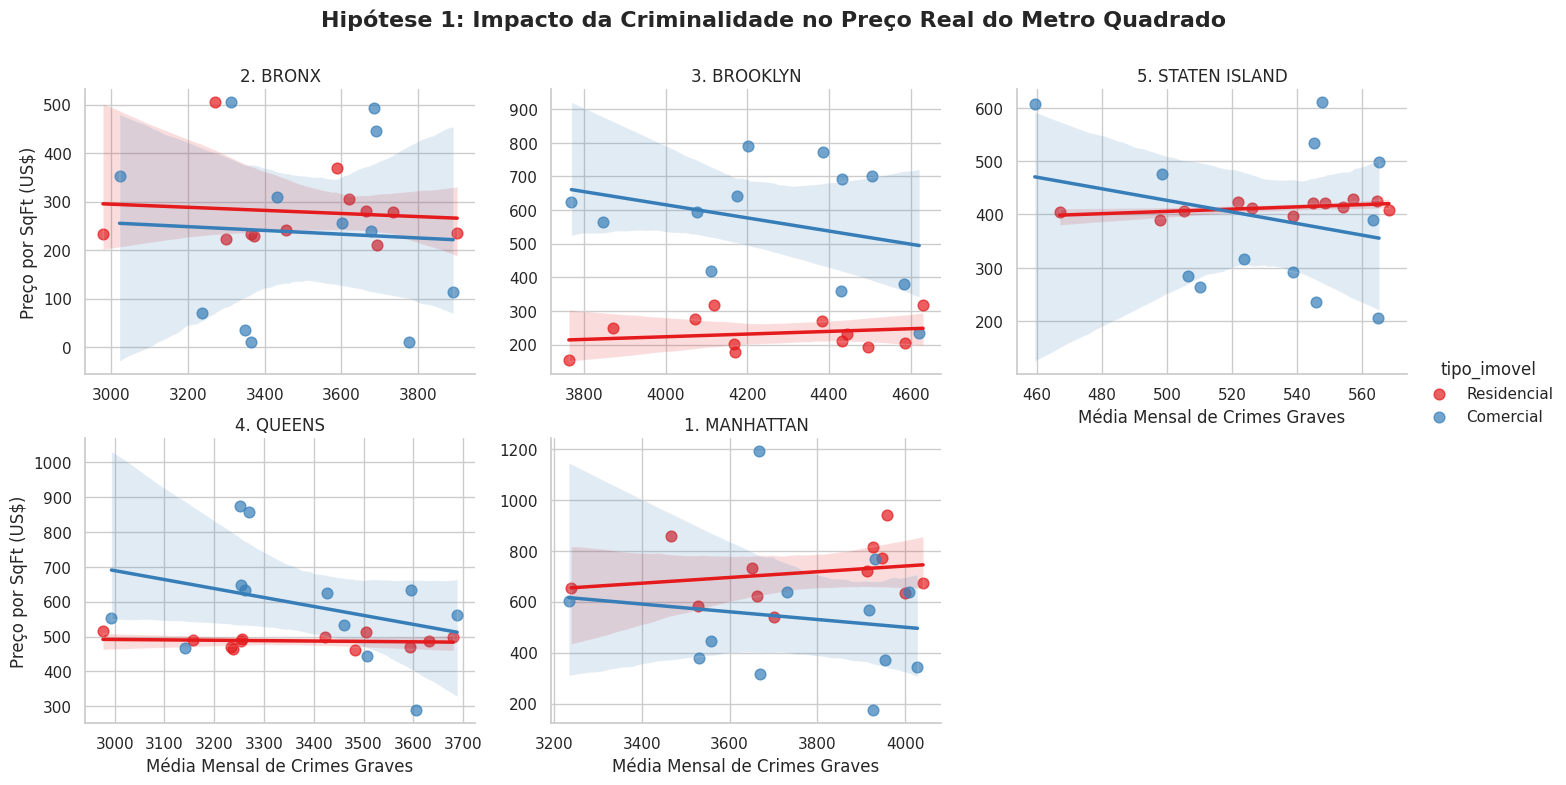

In [ ]:
query_h1_otimizada = f"""
    SELECT
        CASE BOROUGH
            WHEN 1 THEN '1. MANHATTAN'
            WHEN 2 THEN '2. BRONX'
            WHEN 3 THEN '3. BROOKLYN'
            WHEN 4 THEN '4. QUEENS'
            WHEN 5 THEN '5. STATEN ISLAND'
        END AS nome_bairro,
        sale_month,
        CASE
            WHEN "RESIDENTIAL UNITS" > 0 AND "COMMERCIAL UNITS" = 0 THEN 'Residencial'
            WHEN "COMMERCIAL UNITS" > 0 AND "RESIDENTIAL UNITS" = 0 THEN 'Comercial'
            ELSE 'Misto'
        END AS tipo_imovel,
        AVG(qtd_crimes_graves) AS media_crimes_graves,
        SUM("SALE PRICE") / NULLIF(SUM("GROSS SQUARE FEET"), 0) AS preco_medio_sqft
    FROM '{path_parquet}'
    WHERE "GROSS SQUARE FEET" > 100
      AND "SALE PRICE" > 10000
    GROUP BY BOROUGH, sale_month, tipo_imovel
    HAVING tipo_imovel IN ('Residencial', 'Comercial')
"""

df_h1 = con.execute(query_h1_otimizada).df()

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=df_h1,
    x="media_crimes_graves",
    y="preco_medio_sqft",
    hue="tipo_imovel",
    col="nome_bairro",
    col_wrap=3,
    palette="Set1",
    height=4,
    aspect=1.2,
    sharey=False,
    sharex=False,
    scatter_kws={'alpha':0.7, 's': 60},
    line_kws={'linewidth':2.5}
)

g.set_axis_labels("Média Mensal de Crimes Graves", "Preço por SqFt (US$)")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('Hipótese 1: Impacto da Criminalidade no Preço Real do Metro Quadrado', fontsize=16, fontweight='bold')

plt.show()

No Bronx e Manhattan a hipotese se comporta como esperado. O preço do comercial cai enquanto o residencial se mantém.

STATEN ISLAND é um distrito muito mais pacato, residencial e isolado. Pela baixa quantidade de crimes e comportamento de "subúrbio", o impacto visual é bem menor e as linhas são mais curtas.

In [ ]:
linhas_tabela = []
for (bairro, tipo), grupo in df_h1.groupby(['nome_bairro', 'tipo_imovel']):
    if len(grupo) > 1:
        correlacao = grupo['media_crimes_graves'].corr(grupo['preco_medio_sqft'])
    else:
        correlacao = np.nan

    linhas_tabela.append({
        'Distrito (Borough)': bairro,
        'Tipo de Imóvel': tipo,
        'Média Crimes/Mês': round(grupo['media_crimes_graves'].mean(), 1),
        'Preço Médio/SqFt': f"${grupo['preco_medio_sqft'].mean():,.2f}",
        'Correlação (r)': round(correlacao, 3) if not np.isnan(correlacao) else "N/A"
    })

df_resumo_h1 = pd.DataFrame(linhas_tabela)
display(df_resumo_h1)

,Distrito (Borough),Tipo de Imóvel,Média Crimes/Mês,Preço Médio/SqFt,Correlação (r)
0,1. MANHATTAN,Comercial,3762.7,$535.93,-0.137
1,1. MANHATTAN,Residencial,3752.8,$712.54,0.240
2,2. BRONX,Comercial,3503.4,$236.74,-0.053
3,2. BRONX,Residencial,3495.2,$279.03,-0.097
4,3. BROOKLYN,Comercial,4261.3,$564.72,-0.306
5,3. BROOKLYN,Residencial,4260.7,$233.70,0.210
6,4. QUEENS,Comercial,3371.4,$593.79,-0.329
7,4. QUEENS,Residencial,3369.3,$487.52,-0.132
8,5. STATEN ISLAND,Comercial,530.7,$393.01,-0.240
9,5. STATEN ISLAND,Residencial,532.9,$412.70,0.550


##Modelagem com Machine Learning

Como é um problema de regressão e quero prever o valor de imóveis, serão usados os seguintes modelos: Regressão linear, KNN, Random Forest e Xgboost. Alguns modelos foram desconsiderados por exigirem muito esforço da maquina.


###Implementação de Modelos

In [ ]:
df = pd.read_parquet('dados/nyc_dados_finais_limpos_v2.parquet')
df_ml = df.copy()

####Algumas Features

In [ ]:
for col in df_ml.select_dtypes(include='category').columns:
    df_ml[col] = df_ml[col].astype(str)

df_ml['age_at_sale'] = (df_ml['sale_year'] - df_ml['YEAR BUILT']).clip(lower=0)

total_crimes = df_ml['qtd_crimes_graves'] + df_ml['qtd_crimes_leves']
df_ml['crimes_ratio'] = df_ml['qtd_crimes_graves'] / total_crimes.replace(0, float('nan'))

df_ml['sqft_ratio'] = df_ml['GROSS SQUARE FEET'] / df_ml['LAND SQUARE FEET'].replace(0, float('nan'))
df_ml['sqft_ratio'] = df_ml['sqft_ratio'].clip(upper=df_ml['sqft_ratio'].quantile(0.99))

df_ml['price_log'] = np.log1p(df_ml['SALE PRICE'])

print(f'\nDistribuição original do SALE PRICE:')
print(df_ml['SALE PRICE'].describe())
print(f'\nDistribuição log-transformada (price_log):')
print(df_ml['price_log'].describe())


Distribuição original do SALE PRICE:
count    9.385700e+04
mean     2.186877e+06
std      1.432186e+07
min      1.031400e+04
25%      6.700000e+05
50%      9.000000e+05
75%      1.365000e+06
max      1.080000e+09
Name: SALE PRICE, dtype: float64

Distribuição log-transformada (price_log):
count    93857.000000
mean        13.845698
std          0.863286
min          9.241354
25%         13.415034
50%         13.710151
75%         14.126666
max         20.800227
Name: price_log, dtype: float64


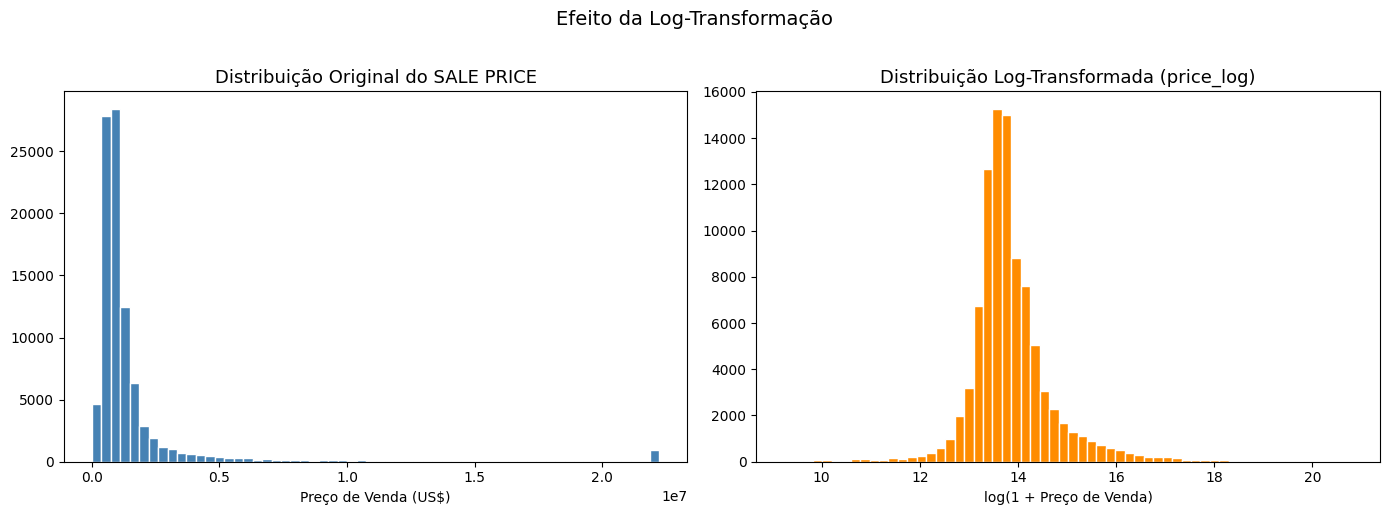

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = df_ml['SALE PRICE'].quantile(0.99)
axes[0].hist(df_ml['SALE PRICE'].clip(upper=cap), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição Original do SALE PRICE', fontsize=13)
axes[0].set_xlabel('Preço de Venda (US$)')

axes[1].hist(df_ml['price_log'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Distribuição Log-Transformada (price_log)', fontsize=13)
axes[1].set_xlabel('log(1 + Preço de Venda)')
#Isso ajuda a distruibuição de preço a ficar mais perto de uma normal, porque muitos modelos funcionam melhor com distribuição normal
plt.suptitle('Efeito da Log-Transformação', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
FEATURES_NUM = [
    'BOROUGH', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
    'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
    'Latitude', 'Longitude',
    'qtd_crimes_graves', 'qtd_crimes_leves', 'media_juros_hipoteca',
    'sale_year', 'sale_month', 'sale_day_of_week',
    'age_at_sale', 'crimes_ratio', 'sqft_ratio'
]

FEATURES_TARGET_ENC = ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY']

df_ml['TAX_CLASS_NUM'] = pd.to_numeric(
    df_ml['TAX CLASS AT TIME OF SALE'].astype(str).str.extract(r'(\d)')[0])
FEATURES_NUM.append('TAX_CLASS_NUM')

FEATURES_ALL = FEATURES_NUM + FEATURES_TARGET_ENC
TARGET = 'price_log'

df_clean = df_ml[FEATURES_ALL + [TARGET, 'SALE PRICE']].copy()
print(f'Dataset para modelagem: {df_clean.shape}')
print(f'Features numéricas    : {len(FEATURES_NUM)}')
print(f'Features Target Enc.  : {len(FEATURES_TARGET_ENC)}')

Dataset para modelagem: (93857, 23)
Features numéricas    : 19
Features Target Enc.  : 2


####Funções Auxiliares

In [ ]:
def evaluate_model(name, y_true_log, y_pred_log, y_true_orig):
    """Avalia o modelo em escala log e converte métricas para US$ (escala original)."""
    y_pred_orig = np.expm1(y_pred_log)
    rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae_orig  = mean_absolute_error(y_true_orig, y_pred_orig)
    r2        = r2_score(y_true_log, y_pred_log)
    safe_orig = np.where(y_true_orig == 0, float('nan'), y_true_orig)
    mape = float(np.nanmean(np.abs((y_true_orig - y_pred_orig) / safe_orig)) * 100)

    print(f'\n{"="*52}')
    print(f'  Modelo: {name}')
    print(f'  R²         : {r2:.4f}')
    print(f'  RMSE (US$) : ${rmse_orig:,.0f}')
    print(f'  MAE  (US$) : ${mae_orig:,.0f}')
    print(f'  MAPE (%)   : {mape:.2f}%')
    return {'modelo': name, 'R2': round(r2, 4),
            'RMSE': round(rmse_orig, 0), 'MAE': round(mae_orig, 0), 'MAPE': round(mape, 2)}

resultados = []

problema do one-hot enconding, Lembrar: calcula no treino e aplica no teste

In [ ]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """Target Encoding com suavização Bayesiana para variáveis de alta cardinalidade."""
    def __init__(self, cols, smoothing=30):
        self.cols = cols
        self.smoothing = smoothing
        self.global_mean_ = None
        self.maps_ = {}

    def fit(self, X, y):
        df_temp = X[self.cols].copy()
        df_temp['__target__'] = y.values
        self.global_mean_ = float(y.mean())
        for col in self.cols:
            stats = df_temp.groupby(col)['__target__'].agg(['mean', 'count'])
            smoother = stats['count'] / (stats['count'] + self.smoothing)
            self.maps_[col] = smoother * stats['mean'] + (1 - smoother) * self.global_mean_
        return self

    def transform(self, X):
        X_out = X.copy()
        for col in self.cols:
            X_out[col] = X_out[col].map(self.maps_[col]).fillna(self.global_mean_)
        return X_out

print('Classe TargetEncoder definida.')

Classe TargetEncoder definida.


####Divisão treino e teste

In [ ]:
X = df_clean[FEATURES_ALL].copy()
y = df_clean[TARGET].copy()
y_original = df_clean['SALE PRICE'].copy()

X_train, X_test, y_train, y_test, y_train_orig, y_test_orig = train_test_split(
    X, y, y_original, test_size=0.2, random_state=42
)

print(f'Treino : {X_train.shape[0]:,} amostras')
print(f'Teste  : {X_test.shape[0]:,} amostras')

te = TargetEncoder(cols=FEATURES_TARGET_ENC, smoothing=30)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print('Divisão e Target Encoding concluídos!')

Treino : 75,085 amostras
Teste  : 18,772 amostras
Divisão e Target Encoding concluídos!


####Modelo Baseline

Média de todos os imóveis

In [ ]:
y_pred_baseline = np.full(len(y_test), float(y_train.median()))
res_baseline = evaluate_model('Baseline (Mediana)', y_test.values, y_pred_baseline, y_test_orig.values)
resultados.append(res_baseline)


  Modelo: Baseline (Mediana)
  R²         : -0.0258
  RMSE (US$) : $13,457,682
  MAE  (US$) : $1,549,673
  MAPE (%)   : 68.79%


####Regressão Linear

####Random Forest

####XGBoost

####Análise

####Análise de interpretabilidade vs. performance

####Melhor modelo

####Limitações

##Conclusão